I'll use this script to draw summary graphs 
1) TAT for different workloads for a given capacity. 
2) Sensitivity analysis
3) Resilience analysis


In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt





In [8]:
df_experiments=pd.read_csv(r'/Users/varad/Desktop/Lenovo Desktop/Oxford/DPhil Cervical Cancer Scale-up/Code/real_world_sim/Final_Results/Cleaned_data_for_analysis.csv')
df_experiments.head()

df_res_util = pd.read_csv(r'/Users/varad/Desktop/Lenovo Desktop/Oxford/DPhil Cervical Cancer Scale-up/Code/real_world_sim/Final_Results/Res_util_data.csv')
df_res_util.head()

,utilisation_key,resource_name,task,capacity,resource_type,calendar_minutes,scheduled_available_minutes,analysis_start_min,analysis_end_min,denominator_source_key,duration_min,available_person_minutes,utilisation_pct
0,Baseline - Increasing Demand - 5 pap per day,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Cytotechnicians,Cytotechnicians,NaN,3.0,scheduled,480960.0,149040.0,44640.0,525600.0,Cytotechnicians,155562.43340,447120.0,34.79
2,Junior Cytopathologists,Junior Cytopathologists,NaN,5.0,scheduled,480960.0,40080.0,44640.0,525600.0,Junior Cytopathologists,157876.59720,200400.0,78.78
3,Manual Staining Station,Manual Staining Station,NaN,1.0,equipment,480960.0,149040.0,44640.0,525600.0,Cytotechnicians,108780.00000,149040.0,72.99
4,Senior Pathologists,Senior Pathologists,NaN,3.0,scheduled,480960.0,74520.0,44640.0,525600.0,Senior Pathologists,56910.61662,223560.0,25.46


## Experiment 1: Increasing Demand (Cytology)

Box plots of turnaround time (TAT) across all increasing-demand scenarios
(every row up to the next experiment).
The CSV stores summary statistics rather than raw samples, so the boxes are built
from the precomputed quartiles (`min`, `25%`, `50%`, `75%`, `max`) using `Axes.bxp`.

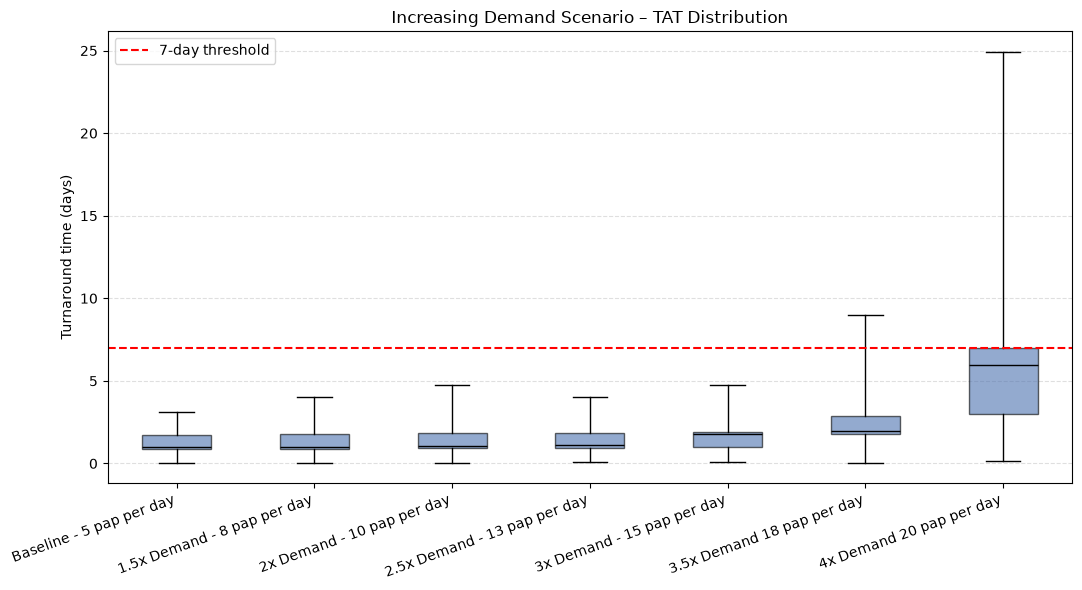

In [9]:
# Box plots for Experiment 1: Increasing Demand
# Take every scenario row from the top until the next experiment header
# (header rows have an empty `count`).
valid = df_experiments["count"].notna()
first_break = (~valid).idxmax() if (~valid).any() else len(df_experiments)
demand = df_experiments.iloc[:first_break].copy()

# The CSV holds summary stats, so build each box from the precomputed quartiles.
box_stats = []
for _, row in demand.iterrows():
    box_stats.append({
        "label": row.iloc[0],
        "whislo": row["min"],
        "q1": row["25%"],
        "med": row["50%"],
        "q3": row["75%"],
        "whishi": row["max"],
        "mean": row["mean"],
        "fliers": [],
    })

fig, ax = plt.subplots(figsize=(11, 6))
ax.bxp(box_stats, showmeans=False, patch_artist=True,
       boxprops=dict(facecolor="#4C72B0", alpha=0.6),
       medianprops=dict(color="black"))

ax.axhline(7, color="red", linestyle="--", linewidth=1.5, label="7-day threshold")
ax.legend(loc="upper left")

ax.set_ylabel("Turnaround time (days)")
ax.set_title("Increasing Demand Scenario \u2013 TAT Distribution")
ax.set_xticklabels([s["label"] for s in box_stats], rotation=20, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## All Experiments

The CSV is a stack of experiment blocks, each introduced by a header row whose
`count` is empty (the first block's title is the first column header). The cell
below splits the file into those blocks and draws a TAT box plot for each, using
the same precomputed-quartile approach and the 7-day threshold line.

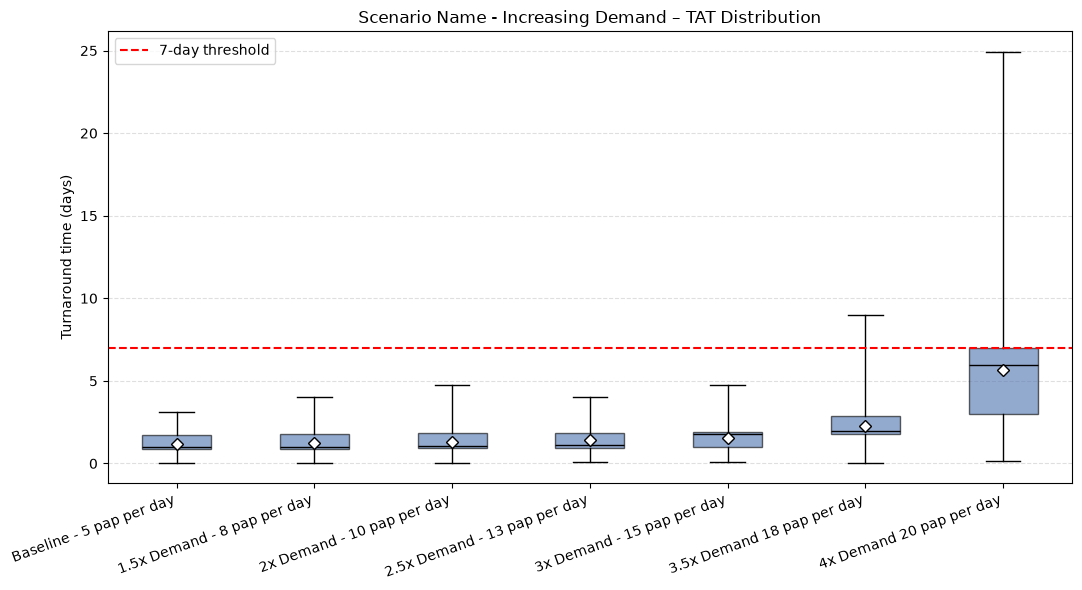

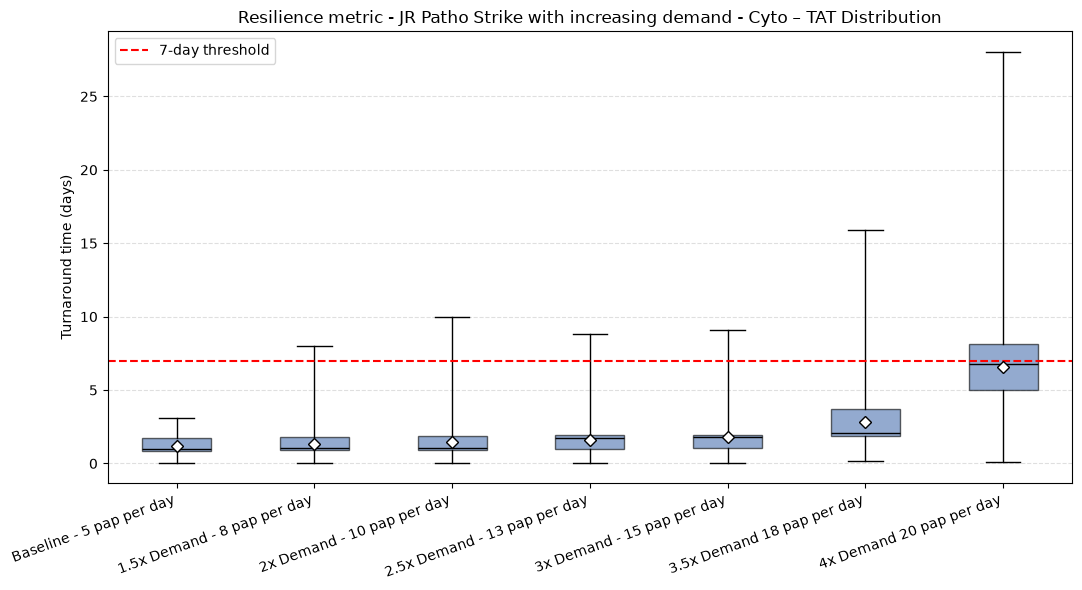

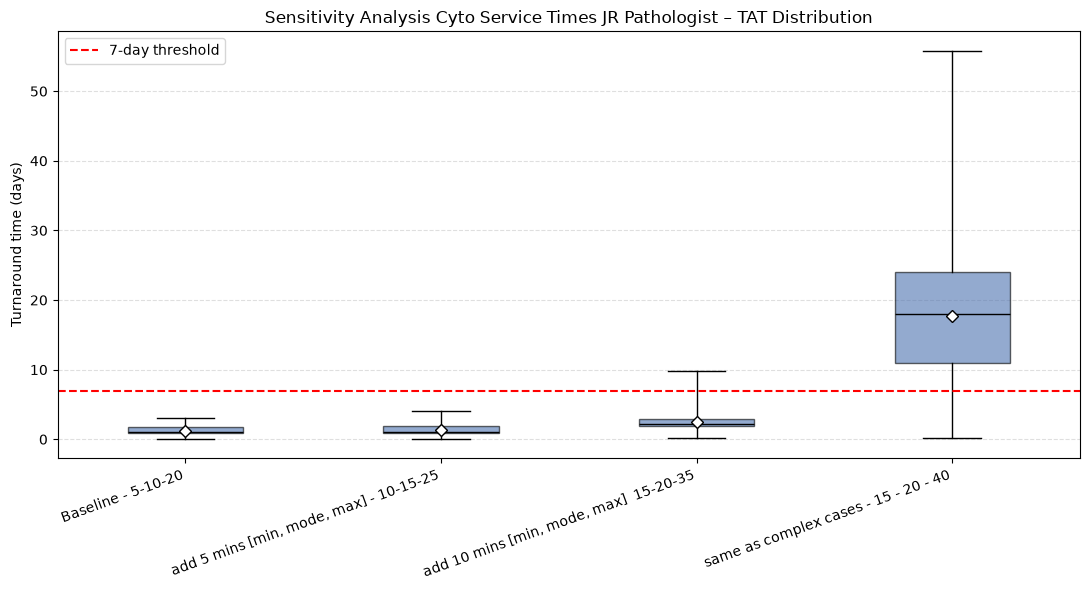

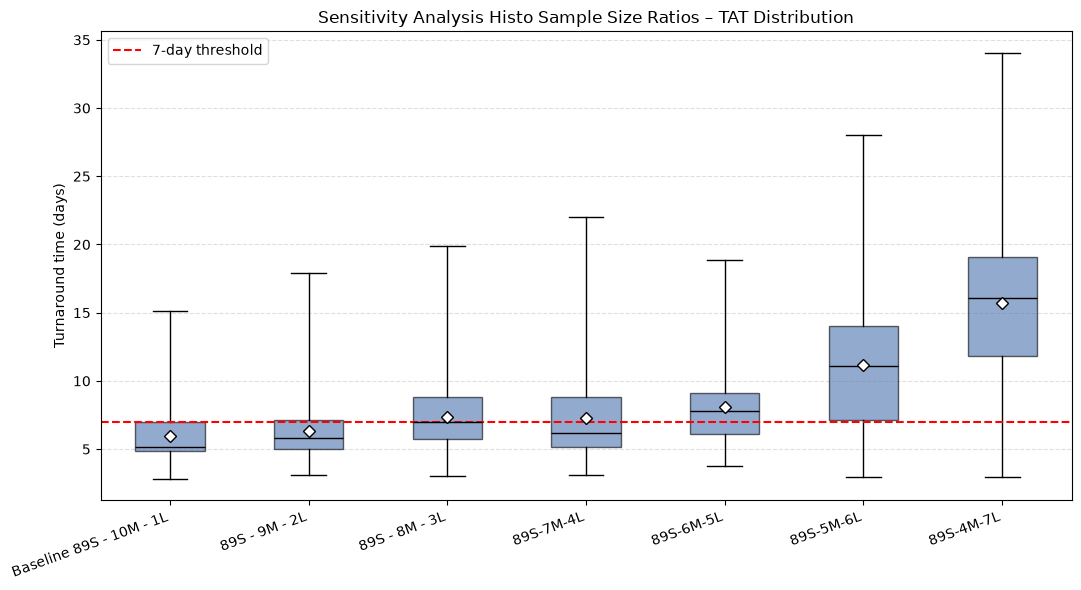

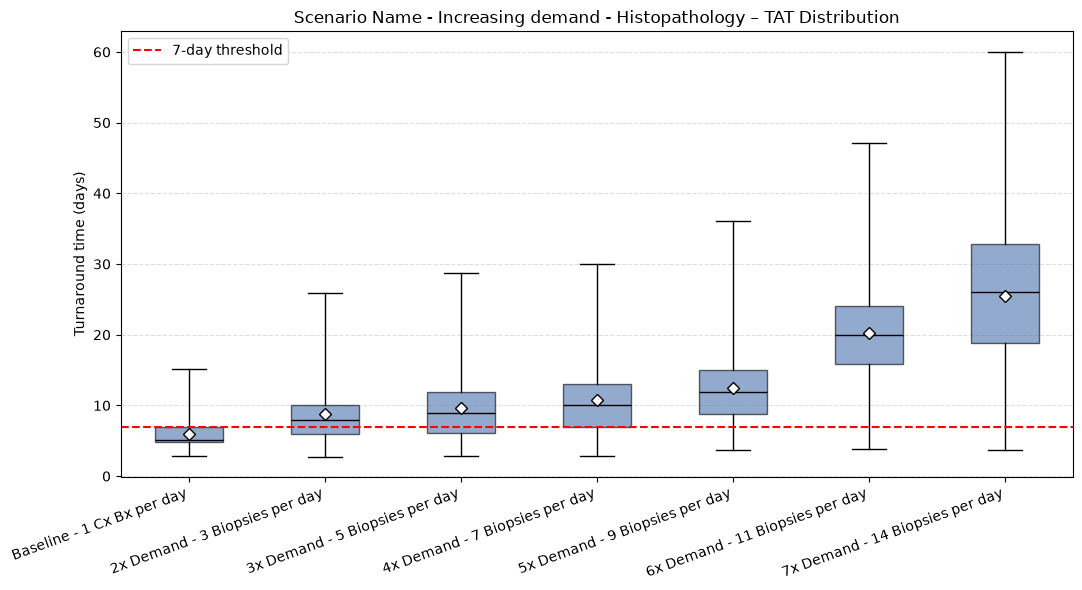

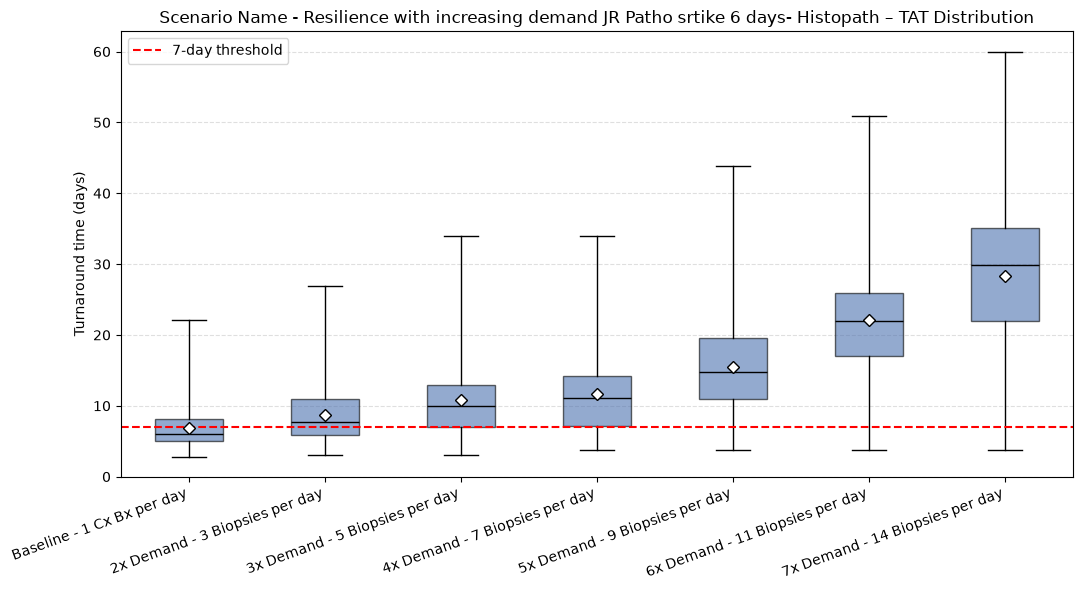

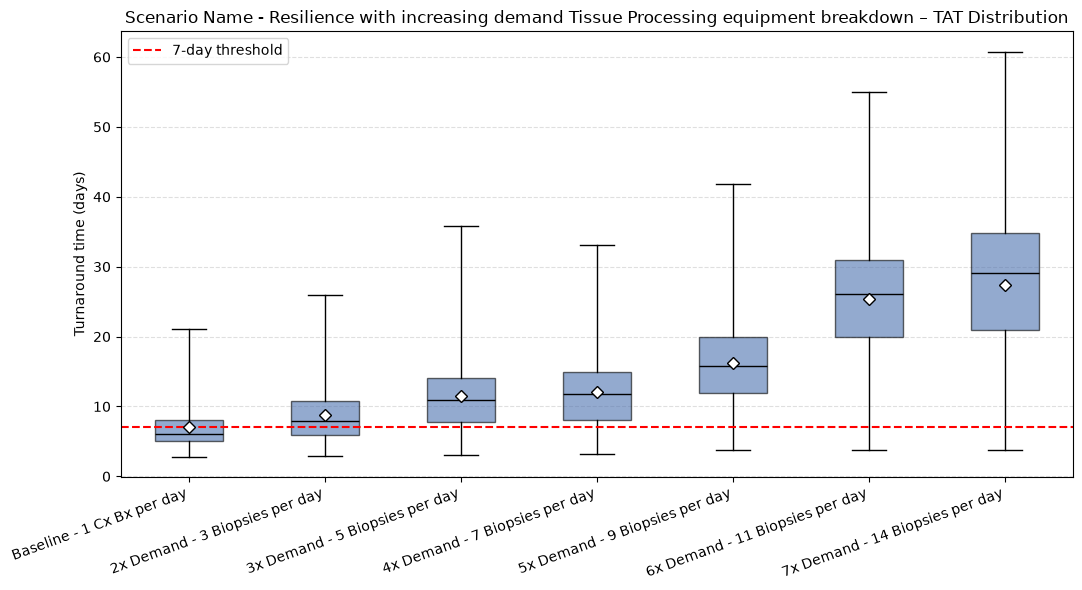

In [6]:
# Split the file into experiment blocks and draw a box plot for each.
label_col = df_experiments.columns[0]

experiments = []
current_title = label_col          # first block is titled by the column header
current_rows = []
for _, row in df_experiments.iterrows():
    label = str(row[label_col]).strip()
    if pd.isna(row["count"]):
        # header or empty row -> close current block, start a new one if titled
        if current_rows:
            experiments.append((current_title, pd.DataFrame(current_rows)))
            current_rows = []
        if label and label.lower() != "nan":
            current_title = label
        continue
    current_rows.append(row)
if current_rows:
    experiments.append((current_title, pd.DataFrame(current_rows)))


def build_box_stats(block):
    return [{
        "label": row.iloc[0],
        "whislo": row["min"],
        "q1": row["25%"],
        "med": row["50%"],
        "q3": row["75%"],
        "whishi": row["max"],
        "mean": row["mean"],
        "fliers": [],
    } for _, row in block.iterrows()]


for title, block in experiments:
    box_stats = build_box_stats(block)

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bxp(box_stats, showmeans=False, patch_artist=True,
           boxprops=dict(facecolor="#4C72B0", alpha=0.6),
           medianprops=dict(color="black"))

    # Histo pathways use a 14-day target; cytology uses 7 days.
    is_histo = any(k in title.lower() for k in ["histo", "biops", "tissue"])
    threshold = 14 if is_histo else 7
    ax.axhline(threshold, color="red", linestyle="--", linewidth=1.5,
               label=f"{threshold}-day threshold")
    ax.legend(loc="upper left")

    ax.set_ylabel("Turnaround time (days)")
    ax.set_title(f"{title} \u2013 TAT Distribution")
    ax.set_xticklabels([s["label"] for s in box_stats], rotation=20, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

## TAT vs Resource Utilisation

For each pathway (cytology and histopathology) the TAT box plot (outcome) is stacked
above a resource-utilisation heatmap (driver), sharing the demand-scenario x-axis.
The heatmap colour is centred at 100% so anything red is at/over capacity — the
bottleneck responsible for the rising TAT above. Scenarios are aligned by position
between the two files (their labels differ slightly), and resources with no reported
utilisation are dropped.

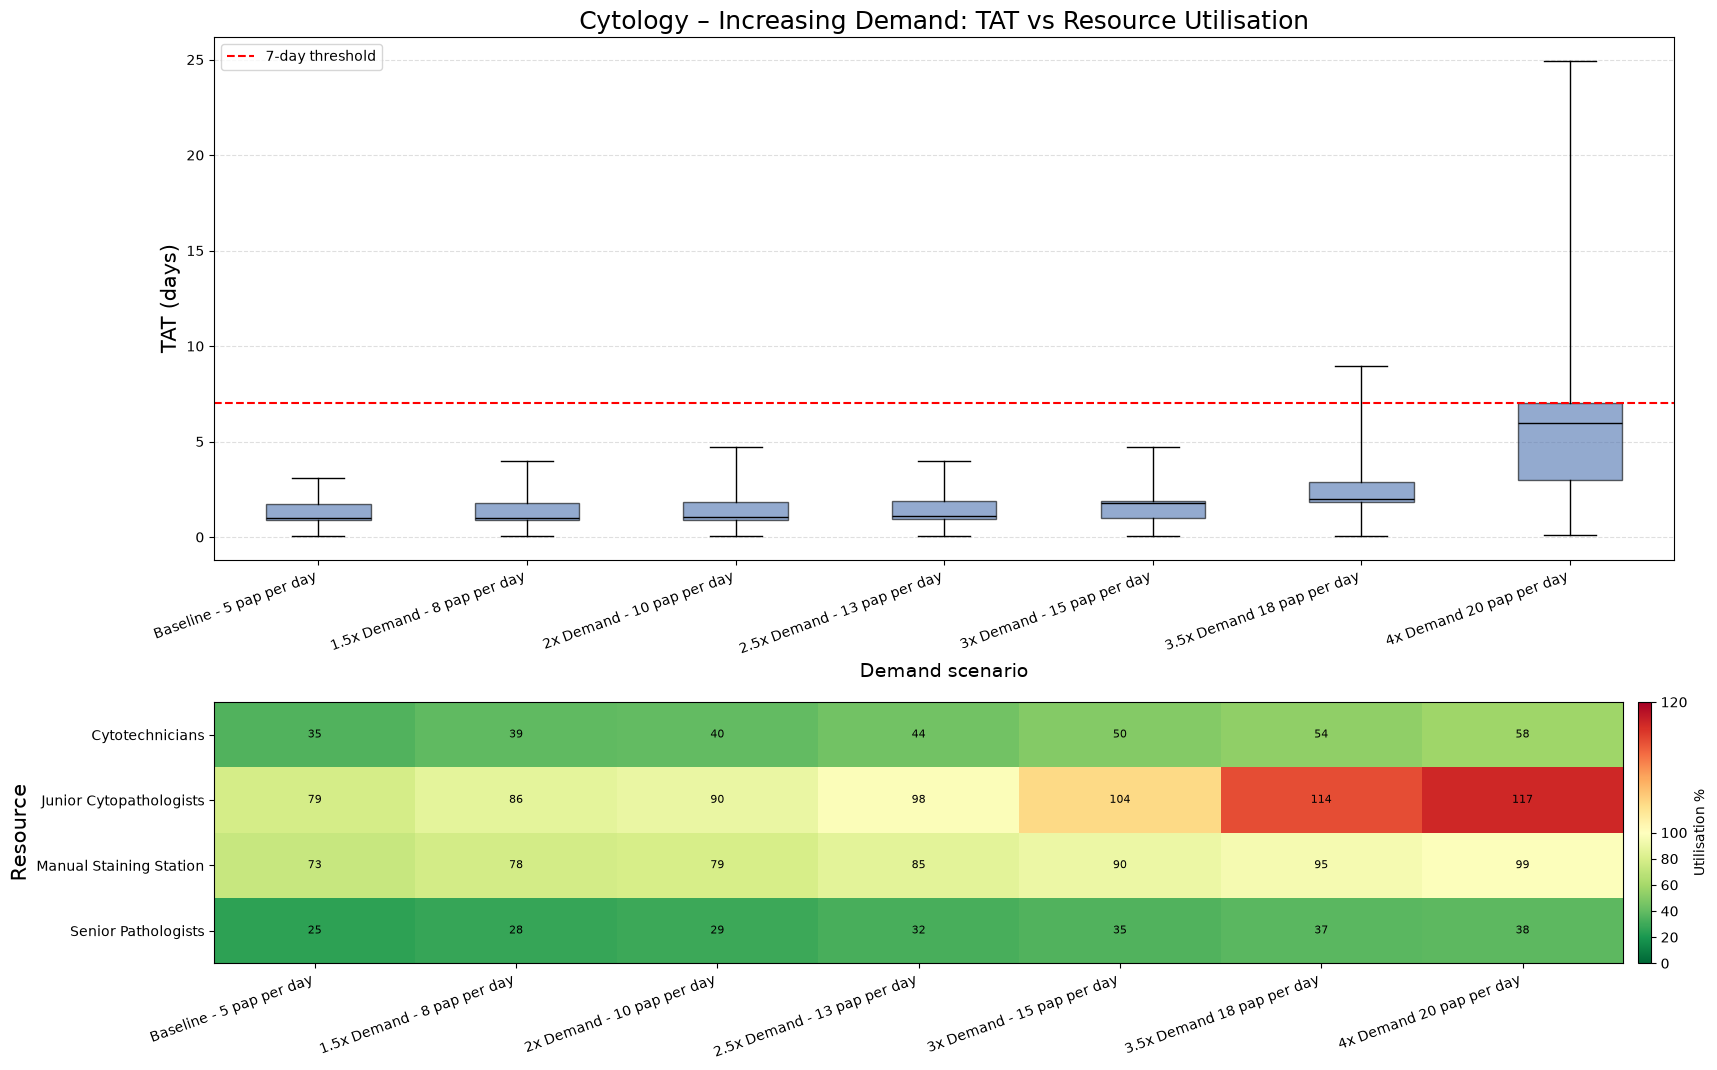

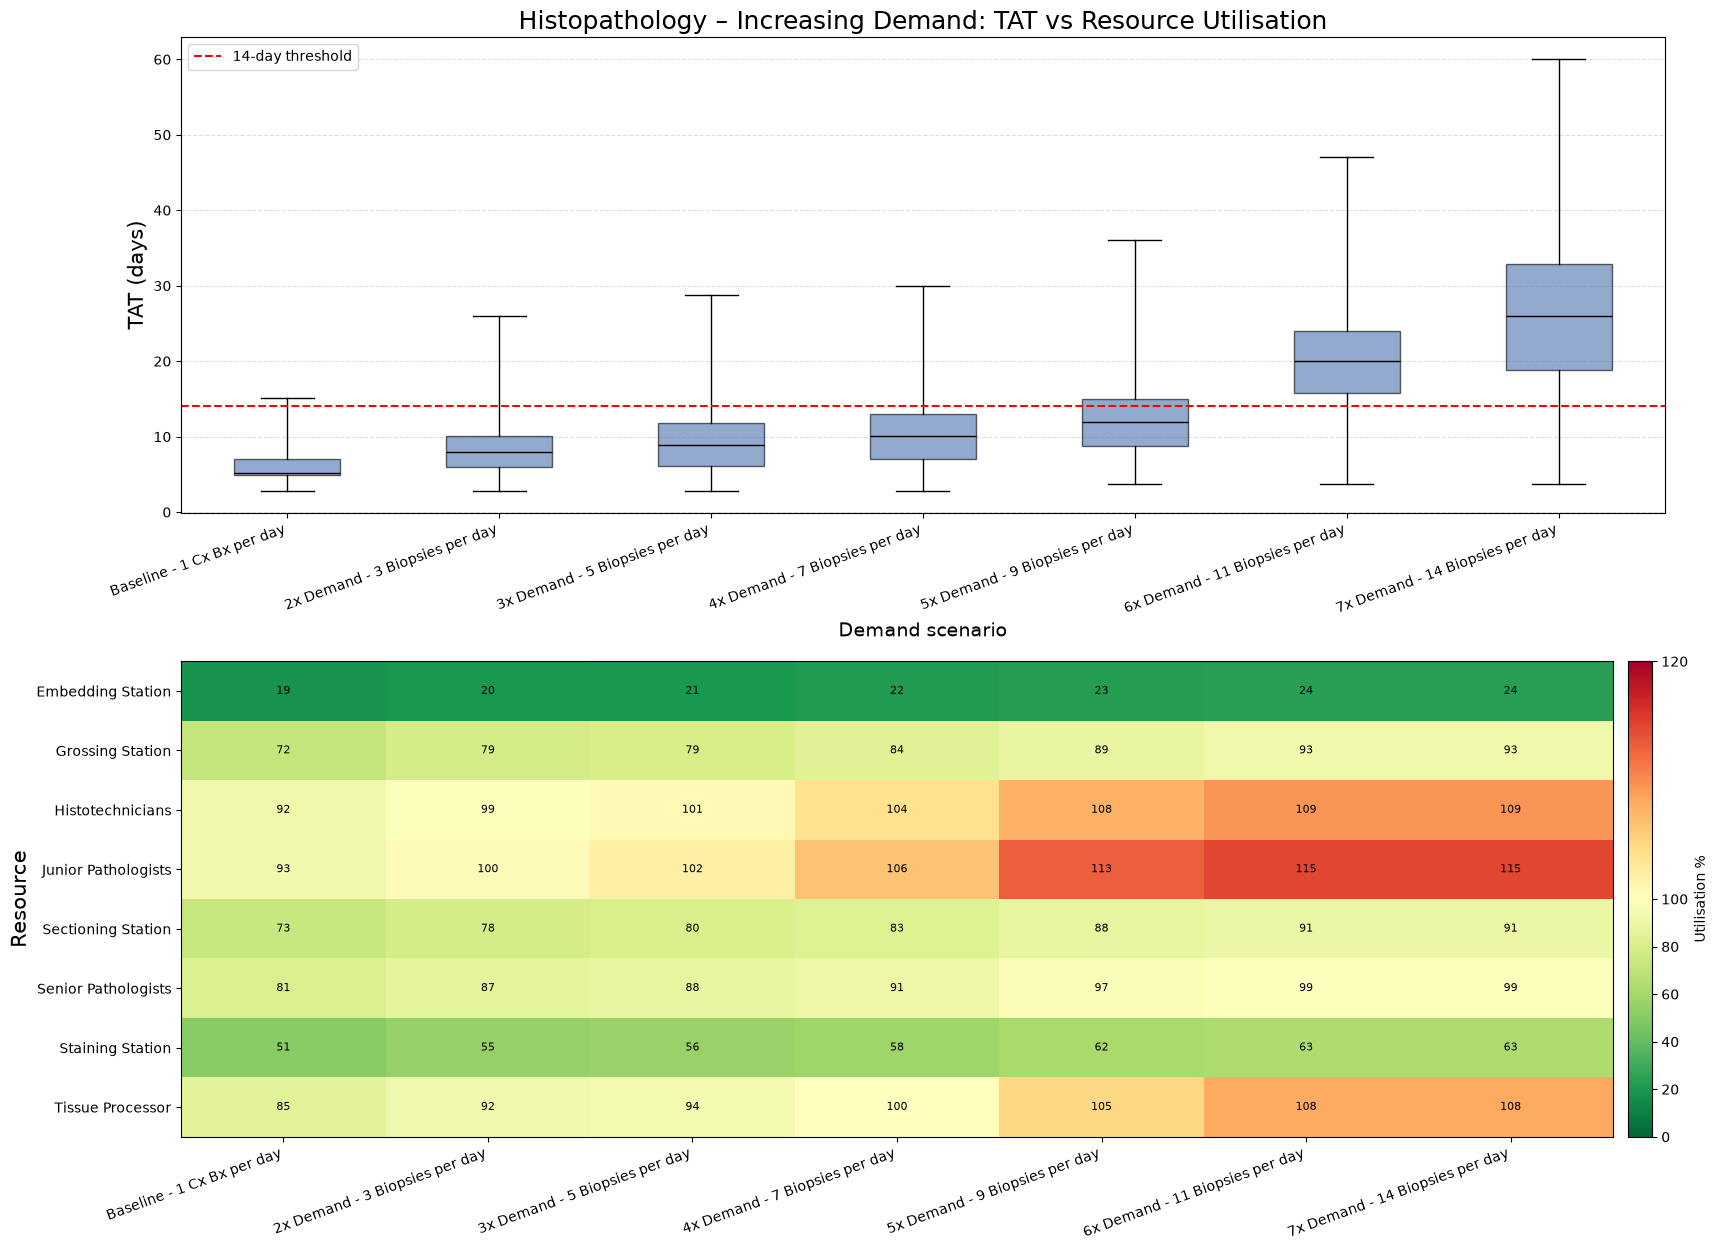

In [13]:
from matplotlib.colors import TwoSlopeNorm

# --- Load the resource-utilisation file (same block structure as the TAT file) ---
util_df = pd.read_csv(
    r'/Users/varad/Desktop/Lenovo Desktop/Oxford/DPhil Cervical Cancer Scale-up/Code/real_world_sim/Final_Results/Res_util_data.csv'
)


def load_util_blocks(u):
    """Split the utilisation file into per-scenario blocks: {label, {resource: pct}}."""
    blocks, current = [], None
    for _, row in u.iterrows():
        key = str(row["utilisation_key"]).strip()
        rname = row["resource_name"]
        if pd.isna(rname):
            # label row: scenario header, section title, or blank
            if key and key.lower() != "nan" and "utilisation percentages" not in key.lower():
                current = {"label": key, "res": {}}
                blocks.append(current)
            continue
        if current is not None:
            current["res"][str(rname).strip()] = pd.to_numeric(
                row["utilisation_pct"], errors="coerce"
            )
    return blocks


CYTO_MARKERS = {"Cytotechnicians", "Junior Cytopathologists"}
HISTO_MARKERS = {"Histotechnicians", "Tissue Processor", "Embedding Station",
                 "Sectioning Station", "Grossing Station"}


def pathway_of(block):
    res = set(block["res"])
    if res & CYTO_MARKERS:
        return "cyto"
    if res & HISTO_MARKERS:
        return "histo"
    return None


def util_matrix(blocks):
    """Return (resources, scenarios, matrix[resource, scenario]) dropping all-NaN resources."""
    scenarios = [b["label"] for b in blocks]
    resources = []
    for b in blocks:
        for r in b["res"]:
            if r not in resources:
                resources.append(r)
    mat = np.full((len(resources), len(scenarios)), np.nan)
    for j, b in enumerate(blocks):
        for i, r in enumerate(resources):
            mat[i, j] = b["res"].get(r, np.nan)
    keep = ~np.all(np.isnan(mat), axis=1)
    return [r for r, k in zip(resources, keep) if k], scenarios, mat[keep]


util_blocks = load_util_blocks(util_df)
cyto_blocks = [b for b in util_blocks if pathway_of(b) == "cyto"]
histo_blocks = [b for b in util_blocks if pathway_of(b) == "histo"]

# TAT blocks parsed earlier (cell above) keyed by title
tat_by_title = {t: b for t, b in experiments}

pairs = [
    ("Cytology \u2013 Increasing Demand", "Scenario Name - Increasing Demand", cyto_blocks, 7),
    ("Histopathology \u2013 Increasing Demand",
     "Scenario Name - Increasing demand - Histopathology", histo_blocks, 14),
]

for pname, tat_title, ublocks, threshold in pairs:
    box_stats = build_box_stats(tat_by_title[tat_title])
    resources, scenarios, mat = util_matrix(ublocks)
    n = len(scenarios)

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, sharex=True,
        figsize=(1.9 * n + 4, 0.45 * len(resources) + 9),
        gridspec_kw={"height_ratios": [4, max(2.0, 0.5 * len(resources))]},
    )

    # Top: TAT box plot (built from precomputed quartiles)
    ax_top.bxp(box_stats, showmeans=False, patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=0.6),
               medianprops=dict(color="black"))
    ax_top.axhline(threshold, color="red", linestyle="--", linewidth=1.5,
                   label=f"{threshold}-day threshold")
    ax_top.legend(loc="upper left")
    ax_top.set_ylabel("TAT (days)", fontsize=15)
    ax_top.set_title(f"{pname}: TAT vs Resource Utilisation", fontsize=18)
    ax_top.grid(axis="y", linestyle="--", alpha=0.4)
    # Show scenario tick labels between the two plots (sharex hides them by default)
    ax_top.set_xticks(range(1, n + 1))
    ax_top.set_xticklabels([s["label"] for s in box_stats], rotation=20, ha="right")
    ax_top.tick_params(axis="x", labelbottom=True)
    ax_top.set_xlabel("Demand scenario", fontsize=14)

    # Bottom: utilisation heatmap, colour centred at 100% (red = at/over capacity)
    norm = TwoSlopeNorm(vmin=0, vcenter=100, vmax=max(120, np.nanmax(mat)))
    cmap = plt.cm.RdYlGn_r.copy()
    cmap.set_bad("#e6e6e6")
    im = ax_bot.imshow(np.ma.masked_invalid(mat), aspect="auto", cmap=cmap, norm=norm,
                       extent=(0.5, n + 0.5, len(resources) - 0.5, -0.5))

    for i in range(len(resources)):
        for j in range(n):
            v = mat[i, j]
            if not np.isnan(v):
                ax_bot.text(j + 1, i, f"{v:.0f}", ha="center", va="center", fontsize=8)

    ax_bot.set_yticks(range(len(resources)))
    ax_bot.set_yticklabels(resources)
    ax_bot.set_xticks(range(1, n + 1))
    ax_bot.set_xticklabels([s["label"] for s in box_stats], rotation=20, ha="right")
    ax_bot.set_xlim(0.5, n + 0.5)
    ax_bot.set_ylabel("Resource", fontsize=15)

    cbar = fig.colorbar(im, ax=ax_bot, orientation="vertical", fraction=0.025, pad=0.01)
    cbar.set_label("Utilisation %")

    plt.tight_layout()
    plt.show()